In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import plotly.graph_objects as go
import plotly.express as px

## Step 2: Load Data
Load the same feature-engineered dataset and perform exactly the same preprocessing as in Task 4.
This is critical because model comparisons are only fair if all models use the same train/test split.

In [2]:
df = pd.read_csv(
    "../data/processed/ev_sales_feature_engineered.csv",
    parse_dates=["Date"]
)

2.3 One-Hot Encode the Categorical Columns

In [3]:
df = pd.get_dummies(
    df,
    columns=["State", "Vehicle_Category"],
    drop_first=True,
    dtype=int
)

2.4 Create Features and Target

In [4]:
X = df.drop(
    columns=[
        "Date",
        "EV_Sales",
        "Month_Name",
        "Year_Month"
    ]
)

y = df["EV_Sales"]

2.5 Create the Same Train/Test Split

In [5]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

2.6 Verify

In [6]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

print("Target Train :", y_train.shape)
print("Target Test  :", y_test.shape)

Training Data : (230, 14)
Testing Data  : (58, 14)
Target Train : (230,)
Target Test  : (58,)


## Step 3: Train the Model

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = rf.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

In [10]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

MAE  : 121.42
MSE  : 30272.22
RMSE : 173.99
R²   : 0.9964
MAPE : 0.0675


Step 6: Actual vs Predicted

In [11]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
230,6100,5617.05
231,5850,6180.85
232,6400,6380.00
233,6900,6954.50
234,7350,7472.50


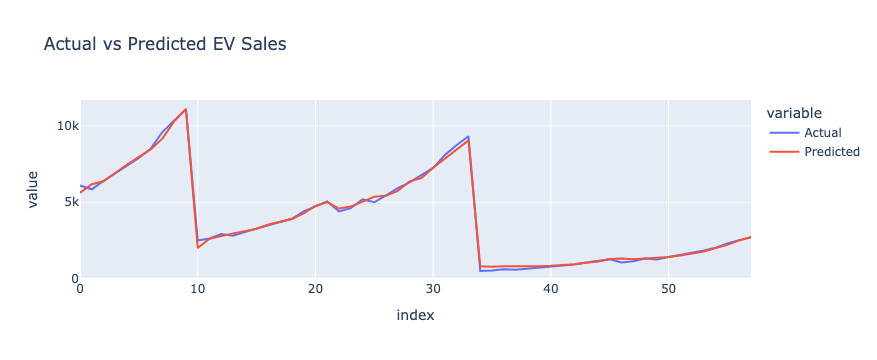

In [12]:
fig = px.line(
    results.reset_index(drop=True),
    y=["Actual", "Predicted"],
    title="Actual vs Predicted EV Sales"
)

fig.show()

## Step 7: Feature Importance 
One of the biggest advantages of Random Forest is that it tells you which features matter most.

In [13]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
6,Rolling_3,0.583643
3,Lag_1,0.364362
4,Lag_2,0.026488
5,Lag_3,0.012329
13,Vehicle_Category_Electric 4W,0.004627
12,Vehicle_Category_Electric 3W,0.002778
7,Rolling_STD_3,0.001519
8,MoM_Growth,0.001439
10,State_Maharashtra,0.001177
1,Month,0.000924


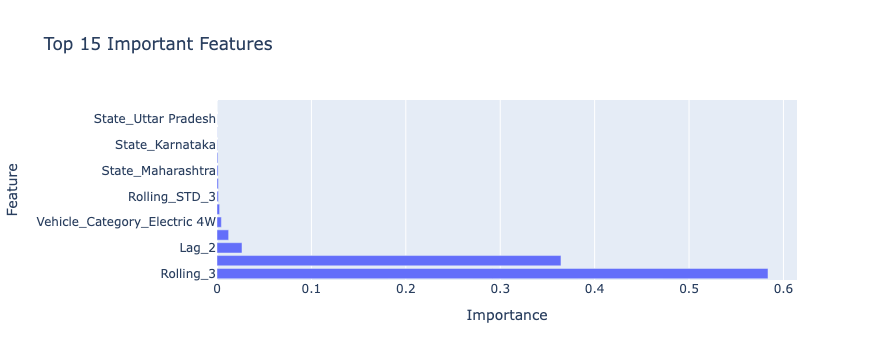

In [14]:
fig = px.bar(
    importance.head(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Important Features"
)

fig.show()

In [15]:
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']